# Regime-Switching Portfolio — HMM + Convex Optimization
Pipeline: data → features → regime detection (walk-forward) → optimization → backtest → results.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import cvxpy as cp
from hmmlearn.hmm import GaussianHMM
np.random.seed(42)

(CVXPY) Jul 18 01:03:54 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jul 18 01:03:54 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


## 1. Data

In [2]:
START = '2010-01-01'
END   = '2024-12-31'
ASSETS = {'EQUITY': '^NSEI', 'GOLD': 'GOLDBEES.NS', 'BOND': 'GILT5YBEES.NS'}
VIX = '^INDIAVIX'

def load_close(tickers, start, end):
    raw = yf.download(list(tickers), start=start, end=end, auto_adjust=True, progress=False)['Close']
    if isinstance(raw, pd.Series):
        raw = raw.to_frame()
    return raw.dropna(how='all')

px = load_close(ASSETS.values(), START, END).rename(columns={v: k for k, v in ASSETS.items()})
vix = load_close([VIX], START, END).rename(columns={VIX: 'VIX'})

data = px.join(vix, how='inner').dropna()
data = data[list(ASSETS.keys()) + ['VIX']]
print(data.shape); data.head()

(906, 4)


Ticker,EQUITY,GOLD,BOND,VIX
Date,,,,
2021-04-07,14819.049805,40.110001,47.654301,20.250000
2021-04-08,14873.799805,40.279999,47.690102,20.309999
2021-04-09,14834.849609,40.450001,47.691200,19.790001
2021-04-12,14310.799805,40.490002,47.713902,23.000000
2021-04-15,14581.450195,40.720001,47.643600,20.889999


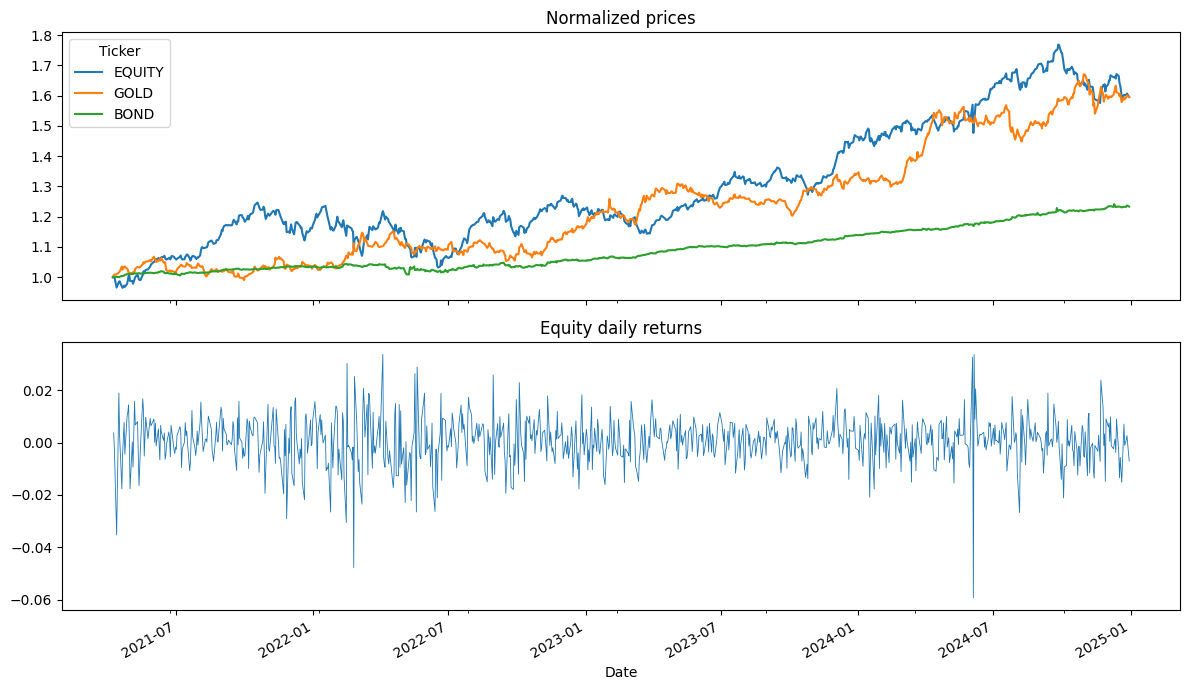

In [3]:
rets = data[list(ASSETS.keys())].pct_change().dropna()
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
(data[list(ASSETS.keys())] / data[list(ASSETS.keys())].iloc[0]).plot(ax=ax[0], title='Normalized prices')
rets['EQUITY'].plot(ax=ax[1], title='Equity daily returns', lw=0.6)
plt.tight_layout()

## 2. Features
Signals that separate calm from stressed markets. Keep everything point-in-time (no future info).

In [4]:
def make_features(rets, vix):
    eq = rets['EQUITY']
    f = pd.DataFrame(index=rets.index)
    for w in (5, 21, 63):
        f[f'mom_{w}'] = eq.rolling(w).sum()
    for w in (5, 21):
        f[f'vol_{w}'] = eq.rolling(w).std()
    f['vix_chg'] = vix['VIX'].reindex(f.index).pct_change(5)
    f['down_vol'] = eq.where(eq < 0).rolling(21, min_periods=5).std()
    f['vix'] = vix['VIX'].reindex(f.index)
    return f.dropna()

feats = make_features(rets, vix)

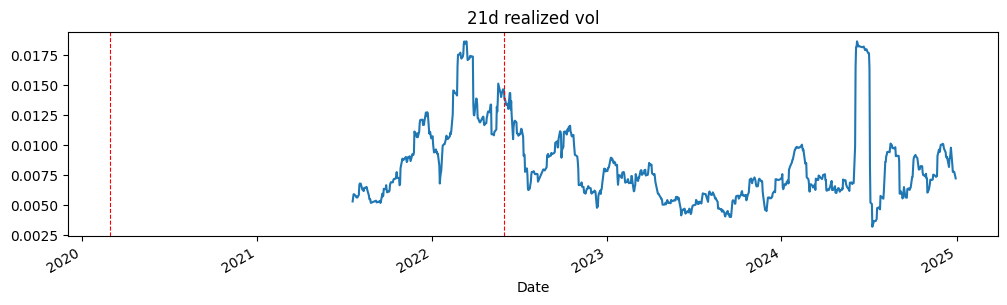

In [5]:
feats['vol_21'].plot(figsize=(12, 3), title='21d realized vol')
for yr in ('2020-03', '2022-06'):
    plt.axvline(pd.Timestamp(yr), color='r', ls='--', lw=0.8)


## 3. Walk-forward scaffolding
Scaling and HMM fitting must see **only past data** at every step.

In [6]:
def zscore_train_only(train, full):
    mu, sd = train.mean(), train.std()
    return (full - mu)/sd

def expanding_splits(n, n_splits=6, min_train=504, test=126):
    splits, start = [], min_train
    while start + test <= n and len(splits) < n_splits:
        splits.append((np.arange(start), np.arange(start, start + test)))
        start += test
    return splits

splits = expanding_splits(len(feats))
len(splits), [(len(a),len(b)) for a, b in splits]

(2, [(504, 126), (630, 126)])

## 4. HMM regime detection
Fit a 2-state Gaussian HMM on scaled features: Crisis vs. Calm. A 3-state fit couldn't
separate Bull from Bear (near-identical mom_21/vol_21/vix across two of the three states,
transition matrix flipping between them almost every day). Bull/Bear is instead derived
from the sign of `mom_21` within the Calm state.

In [7]:
def fit_hmm(X):
    m = GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, random_state=42)
    m.fit(X)
    return m

def label_states(model, X, feat_frame):
    states = model.predict(X)
    prof = feat_frame.assign(state=states).groupby('state').mean()
    crisis = prof['vol_21'].idxmax()
    calm = [s for s in prof.index if s != crisis][0]
    mapping = {crisis: 'Crisis', calm: 'CalmMomentum'}
    return states, mapping, prof

def next_regime(prev_regime, base_regime, mom_21, band=0.01):
    if base_regime == 'Crisis':
        return 'Crisis'
    if prev_regime in ('Bull', 'Bear') and abs(mom_21) < band:
        return prev_regime
    return 'Bull' if mom_21 > 0 else 'Bear'

def apply_hysteresis(base_regimes, mom_series, band=0.01):
    out, prev = [], None
    for b, m in zip(base_regimes, mom_series):
        prev = next_regime(prev, b, m, band)
        out.append(prev)
    return out


### 4.1 Full-sample fit (exposition only — not used in the backtest)
The walk-forward loop in Section 6 refits an HMM on *each training fold only*, which is
correct for the backtest but means no single model ever "sees" the whole history.
Here we fit one more HMM on the full sample purely so we can look at it: the regime
overlay chart and the transition probability matrix. The matrix below is for the raw
2-state HMM (Crisis vs. Calm) — Bull/Bear is a deterministic split of Calm by momentum
sign, not a learned state, so it has no transition probabilities of its own.
This model is never fed into `run_backtest`.

Transition matrix (rows = from, cols = to):
              CalmMomentum  Crisis
CalmMomentum         0.974   0.026
Crisis               0.039   0.961


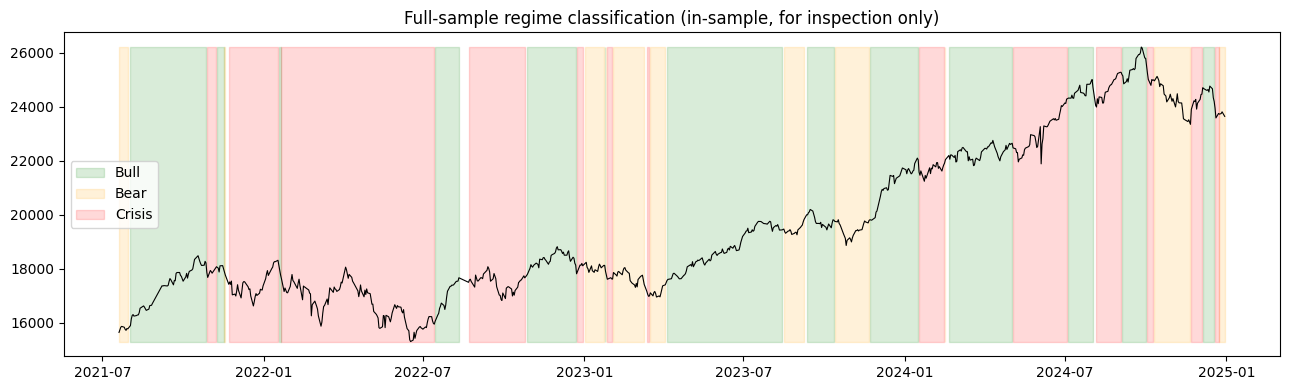

In [8]:
X_full = zscore_train_only(feats, feats).values
full_model = fit_hmm(X_full)
full_states, full_mapping, full_prof = label_states(full_model, X_full, feats)
full_base_regimes = pd.Series(full_states, index=feats.index).map(full_mapping)
full_regimes = pd.Series(
    apply_hysteresis(full_base_regimes, feats['mom_21']),
    index=feats.index
)

labels_order = [full_mapping[s] for s in sorted(full_mapping)]
transmat = pd.DataFrame(full_model.transmat_, index=labels_order, columns=labels_order)
print('Transition matrix (rows = from, cols = to):')
print(transmat.round(3))

fig, ax = plt.subplots(figsize=(13, 4))
eq_full = data['EQUITY'].reindex(full_regimes.index)
ax.plot(eq_full.index, eq_full.values, color='black', lw=0.8)
colors = {'Bull': 'green', 'Bear': 'orange', 'Crisis': 'red'}
for r, c in colors.items():
    mask = full_regimes == r
    ax.fill_between(full_regimes.index, eq_full.min(), eq_full.max(),
                     where=mask, color=c, alpha=0.15, label=r)
ax.set_title('Full-sample regime classification (in-sample, for inspection only)')
ax.legend()
plt.tight_layout()


## 5. Regime → optimal weights (cvxpy)
Different objective per regime. Long-only, fully invested.

In [23]:
def optimize_weights(mu, cov, regime, lam_bull=3.0, lam_bear=8.0):
    n = len(mu)
    w = cp.Variable(n)
    cons = [w >= 0, cp.sum(w) == 1]
    if regime == 'Crisis':
        obj = cp.Minimize(cp.quad_form(w, cov))
    elif regime == 'Bull':
        obj = cp.Maximize(mu @ w - lam_bull * cp.quad_form(w, cov))
    elif regime == 'Bear':
        obj = cp.Maximize(mu @ w - lam_bear * cp.quad_form(w, cov))
    else:
        raise ValueError(f'unknown regime: {regime}')
    cp.Problem(obj, cons).solve(solver=cp.OSQP)
    w_clipped = np.clip(w.value, 0, None)
    return w_clipped / w_clipped.sum()

def robust_mu_cov(hist, shrink=0.05):
    mu = hist.mean().values * shrink
    cov = hist.cov().values
    return mu, cov


## 6. Backtest (walk-forward, with transaction costs)

In [24]:
TC_BPS = 7

def run_backtest(rets, feats, splits, tc_bps=TC_BPS, apply_costs=True, band=0.01):
    asset_rets = rets[list(ASSETS.keys())]
    w_prev = np.ones(asset_rets.shape[1]) / asset_rets.shape[1]
    prev_regime = None
    port_rets, regime_log, turnover_log = [], [], []
    for train_idx, test_idx in splits:
        Xtr = zscore_train_only(feats.iloc[train_idx], feats.iloc[train_idx]).values
        model = fit_hmm(Xtr)
        _, mapping, _ = label_states(model, Xtr, feats.iloc[train_idx])
        for t in test_idx:
            Xt = zscore_train_only(feats.iloc[train_idx], feats.iloc[[t]]).values
            base_regime = mapping[model.predict(Xt)[0]]
            regime = next_regime(prev_regime, base_regime, feats.iloc[t]['mom_21'], band)
            if regime != prev_regime:
                hist = asset_rets.iloc[max(0, t - 63):t]
                mu, cov = robust_mu_cov(hist)
                w = optimize_weights(mu, cov, regime)
            else:
                w = w_prev
            turnover = np.abs(w - w_prev).sum()
            cost = turnover * tc_bps / 1e4 if apply_costs else 0.0
            day_ret = float(asset_rets.iloc[t].values @ w) - cost
            port_rets.append((asset_rets.index[t], day_ret))
            regime_log.append((asset_rets.index[t], regime))
            turnover_log.append((asset_rets.index[t], turnover))
            w_prev = w
            prev_regime = regime
    pr = pd.Series(dict(port_rets)).sort_index()
    rg = pd.Series(dict(regime_log)).sort_index()
    tn = pd.Series(dict(turnover_log)).sort_index()
    return pr, rg, tn

strat_rets, regimes, turnover = run_backtest(rets, feats, splits, apply_costs=True)
strat_rets_gross, _, _ = run_backtest(rets, feats, splits, apply_costs=False)


## 7. Benchmarks + metrics

In [25]:
def benchmarks(rets, regimes_index):
    a = rets[list(ASSETS.keys())].reindex(regimes_index)
    eq_w = a.mean(axis=1)
    w6040 = pd.Series({'EQUITY': 0.6, 'BOND': 0.4, 'GOLD': 0.0}).reindex(a.columns).fillna(0)
    return {'EqualWeight': eq_w, '60/40': a @ w6040.values}

def metrics(r, freq=252):
    r = r.dropna()
    ann_ret = r.mean() * freq
    ann_vol = r.std() * np.sqrt(freq)
    sharpe = ann_ret / ann_vol
    downside = r[r < 0].std() * np.sqrt(freq)
    sortino = ann_ret / downside
    curve = (1 + r).cumprod()
    dd = (curve / curve.cummax() - 1).min()
    calmar = ann_ret / abs(dd)
    return dict(Sharpe=sharpe, Sortino=sortino, MaxDD=dd, Calmar=calmar, AnnRet=ann_ret)



## 8. Results

In [26]:
bms = benchmarks(rets, strat_rets.index)
table = pd.DataFrame({
    'Dynamic (net of costs)': metrics(strat_rets),
    'Dynamic (gross)': metrics(strat_rets_gross),
    **{k: metrics(v) for k, v in bms.items()}
}).T
table['AnnTurnover'] = np.nan
table.loc['Dynamic (net of costs)', 'AnnTurnover'] = turnover.mean() * 252
table.loc['Dynamic (gross)', 'AnnTurnover'] = turnover.mean() * 252
table.loc['EqualWeight', 'AnnTurnover'] = 0.0
table.loc['60/40', 'AnnTurnover'] = 0.0
print('Regime distribution (out-of-sample):')
print(regimes.value_counts())
table


Regime distribution (out-of-sample):
Bull      199
Bear       48
Crisis      5
Name: count, dtype: int64


,Sharpe,Sortino,MaxDD,Calmar,AnnRet,AnnTurnover
Dynamic (net of costs),3.031310,4.805632,-0.026746,3.933843,0.105214,5.093057
Dynamic (gross),3.140514,4.956726,-0.026746,4.067141,0.108779,5.093057
EqualWeight,2.835193,5.134444,-0.025524,6.019172,0.153634,0.000000
60/40,2.694629,4.097705,-0.040158,4.187280,0.168154,0.000000


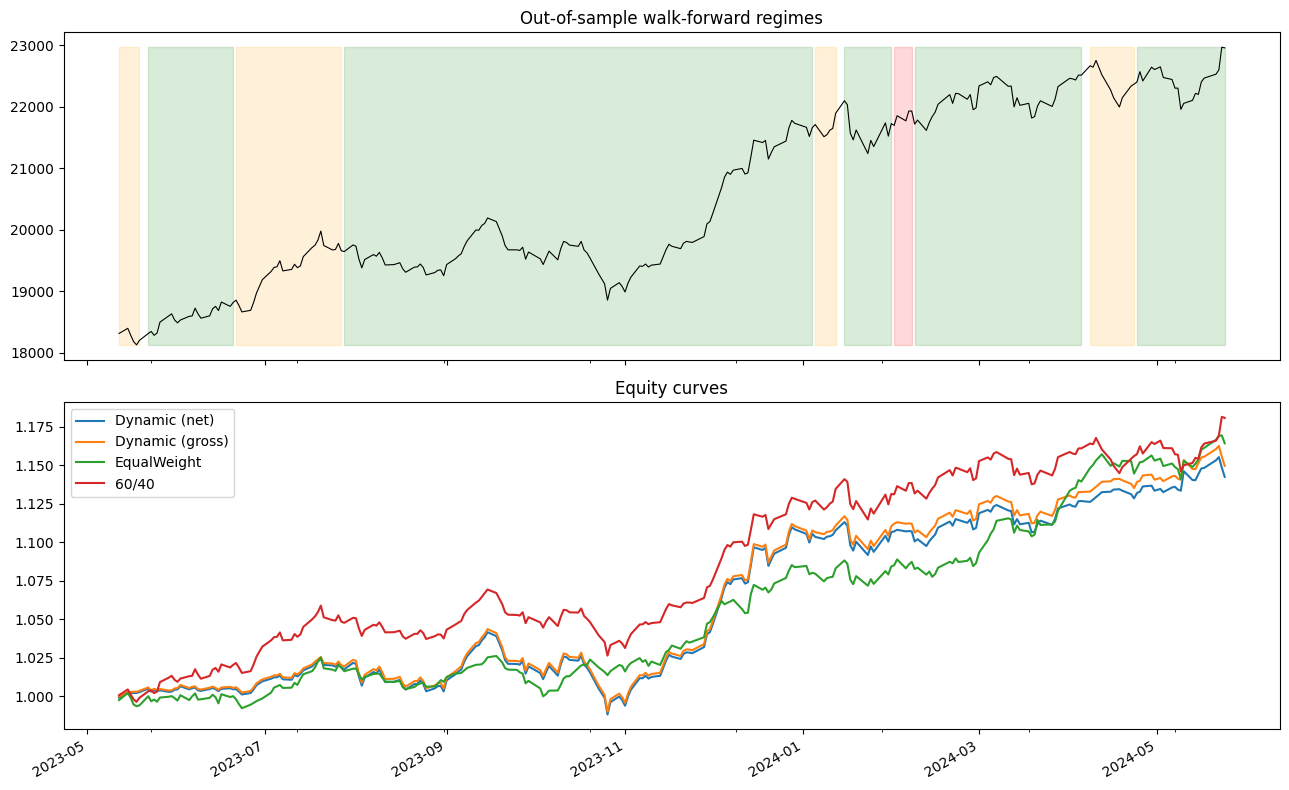

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
colors = {'Bull': 'green', 'Bear': 'orange', 'Crisis': 'red'}
eq = data['EQUITY'].reindex(regimes.index)
ax[0].plot(eq.index, eq.values, color='black', lw=0.8)
for r in colors:
    mask = regimes == r
    ax[0].fill_between(regimes.index, eq.min(), eq.max(), where=mask, color=colors[r], alpha=0.15)
ax[0].set_title('Out-of-sample walk-forward regimes')
(1 + strat_rets).cumprod().plot(ax=ax[1], label='Dynamic (net)')
(1 + strat_rets_gross).cumprod().plot(ax=ax[1], label='Dynamic (gross)')
for k, v in bms.items():
    (1 + v).cumprod().plot(ax=ax[1], label=k)
ax[1].set_title('Equity curves')
ax[1].legend()
plt.tight_layout()
